In [1]:
!pip install albumentations
!pip install opencv-python

# 0. Library Importation

In [3]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
import albumentations as A
from albumentations.pytorch import ToTensorV2
import shutil

from sklearn.model_selection import train_test_split

from utils.helper import export_dataset_to_disk_drive, export_dataset_to_disk_chase, tensor_to_image

/usr/local/lib/python3.12/dist-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno -3] Temporary failure in name resolution>
  data = fetch_version_info()


In [4]:
print("All libraries imported successfully")
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("OpenCV version:", cv2.__version__)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available. Please enable GPU in Kaggle settings.")

!nvidia-smi

All libraries imported successfully
PyTorch version: 2.10.0+cpu
Torchvision version: 0.25.0+cpu
OpenCV version: 4.13.0
CUDA available: False
Device: cpu
GPU is not available. Please enable GPU in Kaggle settings.
/bin/bash: line 1: nvidia-smi: command not found


In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# CHASEDB1 - SOURCE DATA

## 1. Dataset Load

In [6]:
# ===== PATH =====
BASE_PATH = "/kaggle/input/datasets/khoongweihao/chasedb1/"

# Liệt kê toàn bộ file để kiểm tra cấu trúc
all_files = sorted(os.listdir(BASE_PATH))
print(f"Tổng số file: {len(all_files)}")
print("\n10 file đầu tiên:")
for f in all_files[:10]:
    print(" ", f)

Tổng số file: 84

10 file đầu tiên:
  Image_01L.jpg
  Image_01L_1stHO.png
  Image_01L_2ndHO.png
  Image_01R.jpg
  Image_01R_1stHO.png
  Image_01R_2ndHO.png
  Image_02L.jpg
  Image_02L_1stHO.png
  Image_02L_2ndHO.png
  Image_02R.jpg


In [7]:
# ===== LOAD TẤT CẢ ĐƯỜNG DẪN =====
# CHASEDB1 chứa tất cả file chung 1 thư mục, phân biệt bằng suffix tên file

image_paths    = []
manual_1_paths = []
manual_2_paths = []

for fname in sorted(all_files):
    # Ảnh gốc: Image_01L.jpg hoặc Image_01R.jpg
    if fname.endswith(".jpg") and fname.startswith("Image_"):
        img_id = fname.replace(".jpg", "")  # ví dụ: Image_01L
        
        manual_1_name = f"{img_id}_1stHO.png"
        manual_2_name = f"{img_id}_2ndHO.png"

        # Chỉ thêm nếu cả 2 manual tồn tại
        if (
            os.path.exists(os.path.join(BASE_PATH, manual_1_name)) and
            os.path.exists(os.path.join(BASE_PATH, manual_2_name))
        ):
            image_paths.append(os.path.join(BASE_PATH, fname))
            manual_1_paths.append(os.path.join(BASE_PATH, manual_1_name))
            manual_2_paths.append(os.path.join(BASE_PATH, manual_2_name))

print(f"Tổng số ảnh hợp lệ: {len(image_paths)}")
print("\nVí dụ 3 sample đầu:")
for i in range(min(3, len(image_paths))):
    print(f"  Image   : {os.path.basename(image_paths[i])}")
    print(f"  Manual1 : {os.path.basename(manual_1_paths[i])}")
    print(f"  Manual2 : {os.path.basename(manual_2_paths[i])}")
    print()

Tổng số ảnh hợp lệ: 28

Ví dụ 3 sample đầu:
  Image   : Image_01L.jpg
  Manual1 : Image_01L_1stHO.png
  Manual2 : Image_01L_2ndHO.png

  Image   : Image_01R.jpg
  Manual1 : Image_01R_1stHO.png
  Manual2 : Image_01R_2ndHO.png

  Image   : Image_02L.jpg
  Manual1 : Image_02L_1stHO.png
  Manual2 : Image_02L_2ndHO.png



In [8]:
# ===== SPLIT TRAIN / VAL / TEST =====
# Split test
train_val_img, test_img, train_val_m1, test_m1, train_val_m2, test_m2 = train_test_split(
    image_paths, manual_1_paths, manual_2_paths, test_size=4, random_state=42
)

# Split val
train_img, val_img, train_m1, val_m1, train_m2, val_m2 = train_test_split(
    train_val_img, train_val_m1, train_val_m2, test_size=4, random_state=42
)

print(f"Train : {len(train_img)} ảnh")
print(f"Val   : {len(val_img)} ảnh")
print(f"Test  : {len(test_img)} ảnh")

Train : 20 ảnh
Val   : 4 ảnh
Test  : 4 ảnh


## 2. Data Augment + Loader

In [9]:
class CHASEDataset(Dataset):
    def __init__(self, image_paths, manual_1_paths, manual_2_paths=None,
                 img_size=(256, 256), transform=None, multiplier=1):
        self.image_paths    = image_paths
        self.manual_1_paths = manual_1_paths
        self.manual_2_paths = manual_2_paths  # None nếu không dùng
        self.img_size       = img_size
        self.transform      = transform
        self.multiplier     = multiplier

    def __len__(self):
        return len(self.image_paths) * self.multiplier

    def __getitem__(self, idx):
        real_idx = idx % len(self.image_paths)

        # ===== 1. LOAD DATA =====
        img      = np.array(Image.open(self.image_paths[real_idx]).convert("RGB"), dtype=np.uint8)
        manual_1 = np.array(Image.open(self.manual_1_paths[real_idx]).convert("L"), dtype=np.uint8)

        if self.manual_2_paths is not None:
            manual_2 = np.array(Image.open(self.manual_2_paths[real_idx]).convert("L"), dtype=np.uint8)

        # ===== 2. RESIZE =====
        img      = cv2.resize(img,      self.img_size)
        manual_1 = cv2.resize(manual_1, self.img_size, interpolation=cv2.INTER_NEAREST)

        if self.manual_2_paths is not None:
            manual_2 = cv2.resize(manual_2, self.img_size, interpolation=cv2.INTER_NEAREST)

        # ===== 3. AUGMENTATION =====
        if self.transform is not None:
            masks_list = [manual_1]
            if self.manual_2_paths is not None:
                masks_list.append(manual_2)

            augmented = self.transform(image=img, masks=masks_list)

            img      = augmented['image']       # Tensor (C, H, W), normalized
            manual_1 = augmented['masks'][0]    # numpy uint8

            if self.manual_2_paths is not None:
                manual_2 = augmented['masks'][1]

        # ===== 4. XỬ LÝ MASK → TENSOR =====
        if isinstance(manual_1, torch.Tensor):
            manual_1 = manual_1.numpy()

        manual_1_t = torch.from_numpy(np.array(manual_1 / 255.0, dtype=np.float32)).unsqueeze(0)  # (1, H, W)

        if self.manual_2_paths is not None:
            if isinstance(manual_2, torch.Tensor):
                manual_2 = manual_2.numpy()
            manual_2_t = torch.from_numpy(np.array(manual_2 / 255.0, dtype=np.float32)).unsqueeze(0)
            return img, manual_1_t, manual_2_t

        return img, manual_1_t

In [10]:
train_transform = A.Compose([
    A.Resize(height=256, width=256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=45, p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(height=256, width=256),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [11]:
# Train: manual_1 only
train_dataset = CHASEDataset(train_img, train_m1, manual_2_paths=None, transform=train_transform, multiplier=4)

# Val: manual_1 only
val_dataset = CHASEDataset(val_img, val_m1, manual_2_paths=None, transform=val_transform, multiplier=1)

# Test: both manual_1 and manual_2
test_dataset = CHASEDataset(test_img, test_m1, manual_2_paths=test_m2, transform=val_transform, multiplier=5)

print(f"Train size : {len(train_dataset)}")
print(f"Val size   : {len(val_dataset)}")
print(f"Test size  : {len(test_dataset)}")

Train size : 80
Val size   : 4
Test size  : 20


In [12]:
# ===== CHECK SHAPE OUTPUT =====
# Train
sample_img_t, sample_m1_t = train_dataset[0]

print("Train Dataset check")
print(f"  Image tensor shape  : {sample_img_t.shape}")   # (3, 256, 256)
print(f"  Image max/min       : {sample_img_t.max():.3f} / {sample_img_t.min():.3f}")
print(f"  Manual1 shape       : {sample_m1_t.shape}")    # (1, 256, 256)
print(f"  Manual1 unique vals : {torch.unique(sample_m1_t).tolist()}")

print()

# Test 
sample_img_t, sample_m1_t, sample_m2_t = test_dataset[0]

print("Test Dataset check")
print(f"  Image tensor shape  : {sample_img_t.shape}")
print(f"  Manual1 shape       : {sample_m1_t.shape}")
print(f"  Manual2 shape       : {sample_m2_t.shape}")

Train Dataset check
  Image tensor shape  : torch.Size([3, 256, 256])
  Image max/min       : 2.249 / -2.118
  Manual1 shape       : torch.Size([1, 256, 256])
  Manual1 unique vals : [0.0, 1.0]

Test Dataset check
  Image tensor shape  : torch.Size([3, 256, 256])
  Manual1 shape       : torch.Size([1, 256, 256])
  Manual2 shape       : torch.Size([1, 256, 256])


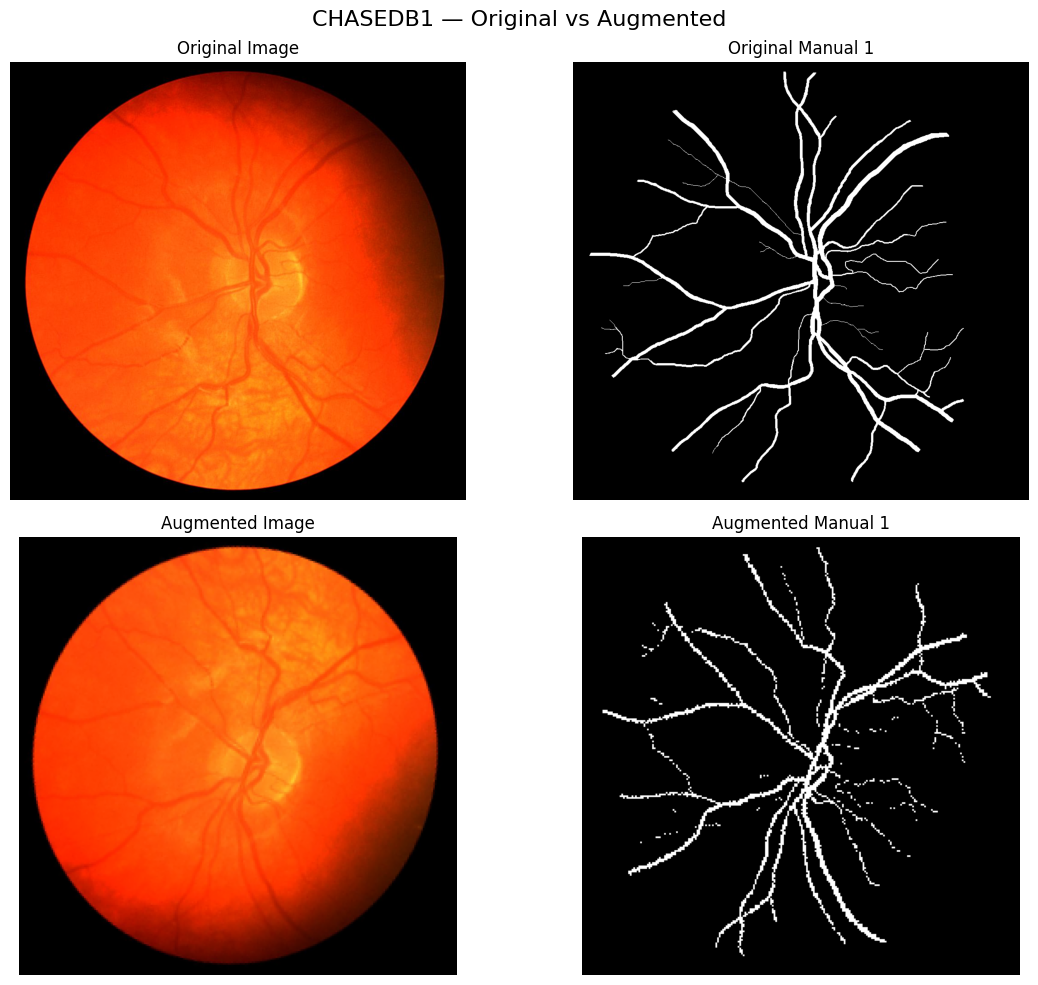

In [13]:
# ===== AUGMENTATION =====
ori_img  = np.array(Image.open(train_img[0]).convert("RGB"))
ori_m1   = np.array(Image.open(train_m1[0]).convert("L"))

aug_img_t, aug_m1_t = train_dataset[0]

aug_img_vis = tensor_to_image(aug_img_t)
aug_m1_vis  = aug_m1_t.numpy().squeeze()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("CHASEDB1 — Original vs Augmented", fontsize=16)

axes[0, 0].imshow(ori_img)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis('off')

axes[0, 1].imshow(ori_m1, cmap='gray')
axes[0, 1].set_title("Original Manual 1")
axes[0, 1].axis('off')

axes[1, 0].imshow(aug_img_vis)
axes[1, 0].set_title("Augmented Image")
axes[1, 0].axis('off')

axes[1, 1].imshow(aug_m1_vis, cmap='gray')
axes[1, 1].set_title("Augmented Manual 1")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

In [14]:
# ===== DATALOADER =====
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=4, shuffle=False, num_workers=2)

print(f"Train Loader: {len(train_loader)} batch")
print(f"Val   Loader: {len(val_loader)} batch")
print(f"Test  Loader: {len(test_loader)} batch")

print("\nDataLoader shape check (Train):")
for images, manuals in train_loader:
    print(f"  Image  : {images.shape}")   # (4, 3, 256, 256)
    print(f"  Manual : {manuals.shape}")  # (4, 1, 256, 256)
    break

print("\nDataLoader shape check (Test):")
for images, manual_1, manual_2 in test_loader:
    print(f"  Image    : {images.shape}")
    print(f"  Manual 1 : {manual_1.shape}")
    print(f"  Manual 2 : {manual_2.shape}")
    break

Train Loader: 20 batch
Val   Loader: 1 batch
Test  Loader: 5 batch

DataLoader shape check (Train):
  Image  : torch.Size([4, 3, 256, 256])
  Manual : torch.Size([4, 1, 256, 256])

DataLoader shape check (Test):
  Image    : torch.Size([4, 3, 256, 256])
  Manual 1 : torch.Size([4, 1, 256, 256])
  Manual 2 : torch.Size([4, 1, 256, 256])


In [15]:
EXPORT_BASE = "/kaggle/working/CHASEDB1_Export"
os.makedirs(EXPORT_BASE, exist_ok=True)

export_dataset_to_disk_chase(train_dataset, "train", has_manual_2=False)
export_dataset_to_disk_chase(val_dataset, "val", has_manual_2=False)
export_dataset_to_disk_chase(test_dataset, "test", has_manual_2=True)

print("\nCompressing dataset into ZIP file...")
ZIP_NAME      = "CHASEDB1_processed_dataset"
ZIP_PATH_BASE = f"/kaggle/working/{ZIP_NAME}"
shutil.make_archive(ZIP_PATH_BASE, 'zip', EXPORT_BASE)

print(f"Done! Created at: {ZIP_PATH_BASE}.zip")

Exporting train (80 samples)...


100%|██████████| 80/80 [00:01<00:00, 55.81it/s]


Exporting val (4 samples)...


100%|██████████| 4/4 [00:00<00:00, 41.39it/s]


Exporting test (20 samples)...


100%|██████████| 20/20 [00:00<00:00, 49.67it/s]



Compressing dataset into ZIP file...
Done! Created at: /kaggle/working/CHASEDB1_processed_dataset.zip


# DRIVE - TRANSFER DATA

## 1. Dataset Load

In [16]:
# ===== PATH =====
BASE_PATH = "/kaggle/input/datasets/zionfuo/drive2004/DRIVE/"

train_img_dir = os.path.join(BASE_PATH, "training/images")
train_mask_dir = os.path.join(BASE_PATH, "training/mask")
train_manual_dir = os.path.join(BASE_PATH, "training/1st_manual")

test_img_dir = os.path.join(BASE_PATH, "test/images")
test_mask_dir = os.path.join(BASE_PATH, "test/mask")
test_manual_1_dir = os.path.join(BASE_PATH, "test/1st_manual")
test_manual_2_dir = os.path.join(BASE_PATH, "test/2nd_manual")

In [17]:
# ===== LOAD TRAIN =====
train_images = sorted(os.listdir(train_img_dir))

train_image_paths = []
train_mask_paths = []
train_manual_paths = []

for img_name in train_images:
    img_id = img_name.split('_')[0]
    manual_name = f"{img_id}_manual1.gif"
    mask_name = f"{img_id}_training_mask.gif"
    
    train_image_paths.append(os.path.join(train_img_dir, img_name))
    train_manual_paths.append(os.path.join(train_manual_dir, manual_name))
    train_mask_paths.append(os.path.join(train_mask_dir, mask_name))

In [18]:
# ===== SPLIT TRAIN - VAL =====
train_image_paths, val_image_paths, train_mask_paths, val_mask_paths, train_manual_paths, val_manual_paths = train_test_split(
    train_image_paths, train_mask_paths, train_manual_paths,
    test_size=4, 
    random_state=42
)

In [19]:
# ===== LOAD TEST =====
test_images = sorted(os.listdir(test_img_dir))

test_image_paths = []
test_mask_paths = []
test_manual_1_paths = []
test_manual_2_paths = []

for img_name in test_images:
    img_id = img_name.split('_')[0]
    mask_name = f"{img_id}_test_mask.gif"
    manual_1_name = f"{img_id}_manual1.gif"
    manual_2_name = f"{img_id}_manual2.gif"
    
    test_image_paths.append(os.path.join(test_img_dir, img_name))
    test_mask_paths.append(os.path.join(test_mask_dir, mask_name))
    test_manual_1_paths.append(os.path.join(test_manual_1_dir, manual_1_name))
    test_manual_2_paths.append(os.path.join(test_manual_2_dir, manual_2_name))

## 2. Data Augment + Loader

In [20]:
class DRIVEDataset(Dataset):
    def __init__(self, image_paths, mask_paths, manual_paths, manual_paths_2=None, img_size=(256, 256), transform=None, multiplier=1):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.manual_paths = manual_paths
        self.manual_paths_2 = manual_paths_2
        
        self.img_size = img_size
        self.transform = transform
        self.multiplier = multiplier

    def __len__(self):
        return len(self.image_paths) * self.multiplier

    def __getitem__(self, idx):
        real_idx = idx % len(self.image_paths)

        # ===== 1. LOAD DATA =====
        img_path = self.image_paths[real_idx]
        mask_path = self.mask_paths[real_idx]
        manual_path = self.manual_paths[real_idx]

        # Mở ảnh gốc (RGB) và các masks (Grayscale)
        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")
        manual = Image.open(manual_path).convert("L")

        # Load 2nd_manual nếu đường dẫn được cung cấp
        if self.manual_paths_2 is not None:
            manual_path_2 = self.manual_paths_2[real_idx]
            manual_2 = Image.open(manual_path_2).convert("L")

        # ===== 2. RESIZE =====
        img = img.resize(self.img_size)
        mask = mask.resize(self.img_size, Image.NEAREST)
        manual = manual.resize(self.img_size, Image.NEAREST)
        
        if self.manual_paths_2 is not None:
            manual_2 = manual_2.resize(self.img_size, Image.NEAREST)

        # Ép kiểu Numpy Array
        img = np.array(img, dtype=np.float32)
        mask = np.array(mask, dtype=np.float32)
        manual = np.array(manual, dtype=np.float32)
        
        if self.manual_paths_2 is not None:
            manual_2 = np.array(manual_2, dtype=np.float32)

        # ===== 3. APPLY AUGMENTATION =====
        if self.transform is not None:
            # Gom tất cả các mask vào 1 list để albumentations biến đổi đồng bộ
            masks_list = [mask, manual]
            if self.manual_paths_2 is not None:
                masks_list.append(manual_2)
                
            # Sử dụng key 'masks' thay vì 'mask'
            augmented = self.transform(image=img, masks=masks_list)
            
            img = augmented['image']
            mask = augmented['masks'][0]
            manual = augmented['masks'][1]
            
            if self.manual_paths_2 is not None:
                manual_2 = augmented['masks'][2]

        # ===== 4. NORMALIZE & TENSOR CONVERSION =====
        if isinstance(mask, torch.Tensor):
            mask = mask.numpy()
        if isinstance(manual, torch.Tensor):
            manual = manual.numpy()
            
        mask_t   = torch.tensor(mask / 255.0, dtype=torch.float32).unsqueeze(0)
        manual_t = torch.tensor(manual / 255.0, dtype=torch.float32).unsqueeze(0)
    
        if self.manual_paths_2 is not None:
            if isinstance(manual_2, torch.Tensor):
                manual_2 = manual_2.numpy()
            manual_2_t = torch.tensor(manual_2 / 255.0, dtype=torch.float32).unsqueeze(0)
            return img, mask_t, manual_t, manual_2_t

        return img, mask_t, manual_t

In [21]:
train_transform = A.Compose([
    A.Resize(height=256, width=256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=45, p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(height=256, width=256),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [22]:
train_dataset = DRIVEDataset(train_image_paths, train_mask_paths, train_manual_paths,transform=train_transform, multiplier=5)
val_dataset = DRIVEDataset(val_image_paths, val_mask_paths, val_manual_paths, transform=val_transform, multiplier=1)
test_dataset = DRIVEDataset(test_image_paths, test_mask_paths, test_manual_1_paths, test_manual_2_paths, transform=val_transform, multiplier=1)

print(f"Train size: {len(train_dataset)}")
print(f"Valid size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

Train size: 80
Valid size: 4
Test size: 20


In [23]:
# ===== TEST CLASS DATASET =====
sample_img, sample_mask, sample_manual = train_dataset[0]

print("Dataset check")
print(f"Image tensor shape: {sample_img.shape}")
print(f"Image max/min: {sample_img.max().item()} / {sample_img.min().item()}\n")

print(f"Mask tensor shape: {sample_mask.shape}")
print(f"Mask unique values: {torch.unique(sample_mask).tolist()}\n")

print(f"Manual tensor shape: {sample_manual.shape}")
print(f"Manual unique values: {torch.unique(sample_manual).tolist()}")

Dataset check
Image tensor shape: torch.Size([3, 256, 256])
Image max/min: 2.248908281326294 / -2.1179039478302

Mask tensor shape: torch.Size([1, 256, 256])
Mask unique values: [0.0, 1.0]

Manual tensor shape: torch.Size([1, 256, 256])
Manual unique values: [0.0, 1.0]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2489083].


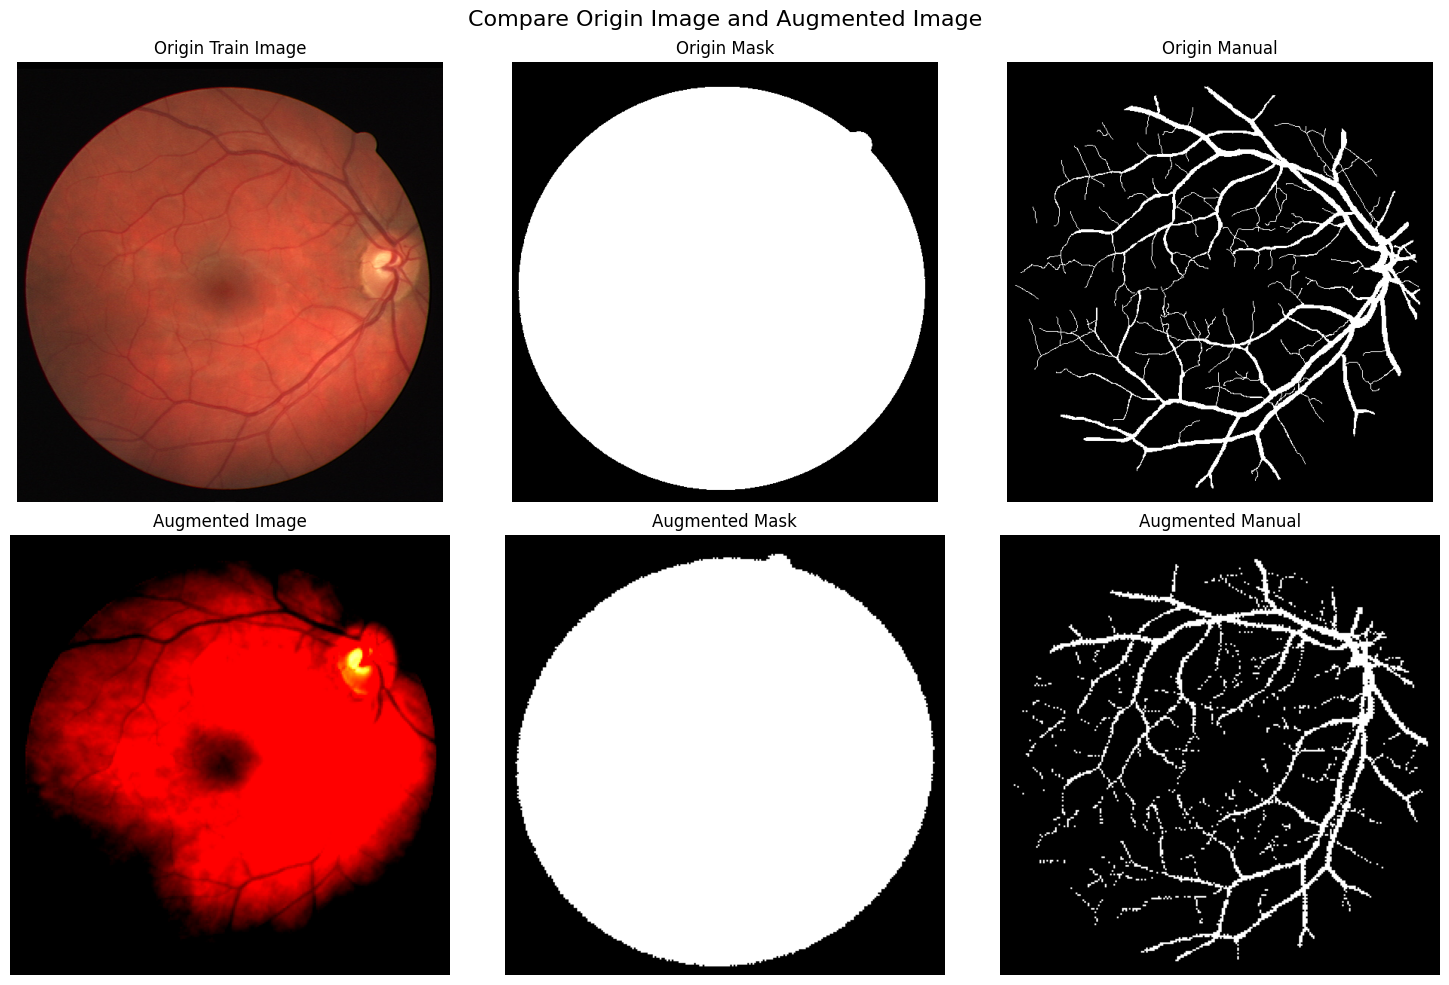

In [24]:
# ===== AUGMENTATION =====
ori_img_path = train_image_paths[0]
ori_mask_path = train_mask_paths[0]
ori_manual_path = train_manual_paths[0]

ori_img = Image.open(ori_img_path).convert("RGB")
ori_mask = Image.open(ori_mask_path).convert("L")
ori_manual = Image.open(ori_manual_path).convert("L")

aug_img_tensor, aug_mask_tensor, aug_manual_tensor = train_dataset[0]

aug_img = aug_img_tensor.numpy().transpose(1, 2, 0)
aug_mask = aug_mask_tensor.numpy().squeeze()
aug_manual = aug_manual_tensor.numpy().squeeze()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Compare Origin Image and Augmented Image", fontsize=16)

axes[0, 0].imshow(ori_img)
axes[0, 0].set_title("Origin Train Image")
axes[0, 0].axis('off')

axes[0, 1].imshow(ori_mask, cmap='gray')
axes[0, 1].set_title("Origin Mask")
axes[0, 1].axis('off')

axes[0, 2].imshow(ori_manual, cmap='gray')
axes[0, 2].set_title("Origin Manual")
axes[0, 2].axis('off')

axes[1, 0].imshow(aug_img)
axes[1, 0].set_title("Augmented Image")
axes[1, 0].axis('off')

axes[1, 1].imshow(aug_mask, cmap='gray')
axes[1, 1].set_title("Augmented Mask")
axes[1, 1].axis('off')

axes[1, 2].imshow(aug_manual, cmap='gray')
axes[1, 2].set_title("Augmented Manual")
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

In [25]:
# ===== DATALOADER =====
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=2)

print(f"Train Loader batch size: {len(train_loader)}")
print(f"Test Loader batch size: {len(test_loader)}")
print(f"Val Loader batch size: {len(val_loader)}")

print("\nDataloader Shape check:")
for images, masks, manual in train_loader:
    print(f"Train Batch - Image shape: {images.shape}")
    print(f"Train Batch - Mask shape: {masks.shape}")
    print(f"Train Batch - Manual shape: {manual.shape}")
    break

Train Loader batch size: 20
Test Loader batch size: 5
Val Loader batch size: 1

Dataloader Shape check:
Train Batch - Image shape: torch.Size([4, 3, 256, 256])
Train Batch - Mask shape: torch.Size([4, 1, 256, 256])
Train Batch - Manual shape: torch.Size([4, 1, 256, 256])


In [26]:
EXPORT_BASE = "/kaggle/working/DRIVE_Export"
os.makedirs(EXPORT_BASE, exist_ok=True)

export_dataset_to_disk_drive(train_dataset, "train")
export_dataset_to_disk_drive(val_dataset, "val")
export_dataset_to_disk_drive(test_dataset, "test")

# ==========================================
# 4. NÉN THƯ MỤC THÀNH FILE ZIP ĐỂ TẢI VỀ
# ==========================================
print("\nCompressing dataset into ZIP file")

ZIP_NAME = "DRIVE_processed_dataset"

ZIP_PATH_BASE = f"/kaggle/working/{ZIP_NAME}" 
shutil.make_archive(ZIP_PATH_BASE, 'zip', EXPORT_BASE)

print(f"Done! Created at: {ZIP_PATH_BASE}.zip")

Exporting train (80 samples)...


100%|██████████| 80/80 [00:02<00:00, 27.96it/s]


Exporting val (4 samples)...


100%|██████████| 4/4 [00:00<00:00, 16.26it/s]


Exporting test (20 samples)...


100%|██████████| 20/20 [00:01<00:00, 14.02it/s]



Compressing dataset into ZIP file
Done! Created at: /kaggle/working/DRIVE_processed_dataset.zip
